ESERCIZIO

Modifica la funzione vae_loo_function aggiungendo un coefficinete beta
Beta deve moltiplicare la kl_loss
Prova ad addestrare il modello con
beta=0
beta=1
beta=5
Cosa noti?


--- Allenamento con BETA = 0 ---
Epoca [1/10] - Loss: 135.00
Epoca [5/10] - Loss: 71.97
Epoca [10/10] - Loss: 67.95

--- Allenamento con BETA = 1 ---
Epoca [1/10] - Loss: 164.29
Epoca [5/10] - Loss: 109.85
Epoca [10/10] - Loss: 106.31

--- Allenamento con BETA = 5 ---
Epoca [1/10] - Loss: 198.16
Epoca [5/10] - Loss: 162.43
Epoca [10/10] - Loss: 158.93


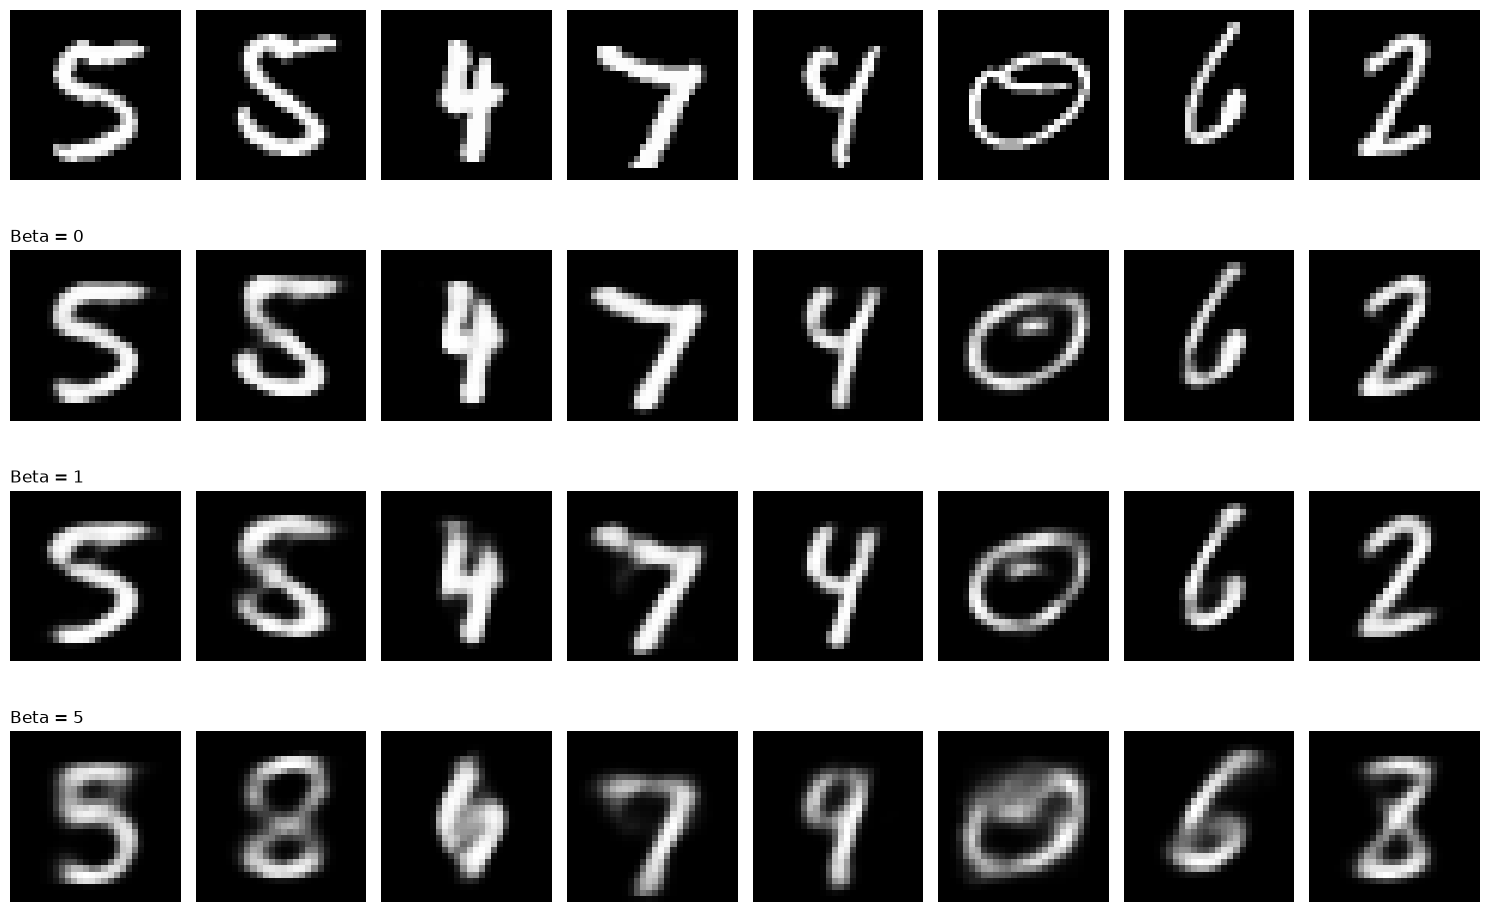

: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
LATENT_DIM = 20
EPOCHS = 10 # Ridotto per velocità, ma sufficiente per vedere le differenze
LR = 1e-3

# --- PREPARAZIONE DATI ---
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- ARCHITETTURA VAE ---
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# --- FUNZIONE DI PERDITA MODIFICATA ---
def vae_loss_function(recon_x, x, mu, logvar, beta):
    # Reconstruction Loss
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # KL Divergence con coefficiente Beta
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + (beta * kl_loss)

# --- FUNZIONE DI ADDESTRAMENTO ---
def train_model(beta_value):
    print(f"\n--- Allenamento con BETA = {beta_value} ---")
    model = VAE(latent_dim=LATENT_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar, beta=beta_value)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        
        avg_loss = train_loss / len(train_loader.dataset)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoca [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.2f}")
    
    return model

# --- ESECUZIONE DEI TEST ---
betas = [0, 1, 5]
results = {}

for b in betas:
    results[b] = train_model(b)

# --- VISUALIZZAZIONE COMPARATIVA ---
with torch.no_grad():
    # Prendiamo un batch di test
    data, _ = next(iter(train_loader))
    data = data.to(device)
    n = 8 # Numero di immagini da mostrare
    
    plt.figure(figsize=(15, 10))
    
    # Mostra Originali
    for i in range(n):
        ax = plt.subplot(len(betas) + 1, n, i + 1)
        plt.imshow(data[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0: ax.set_ylabel("Originali", fontsize=12, labelpad=20)

    # Mostra Ricostruzioni per ogni Beta
    for row, b in enumerate(betas):
        model_beta = results[b]
        recon, _, _ = model_beta(data)
        for i in range(n):
            ax = plt.subplot(len(betas) + 1, n, (row + 1) * n + i + 1)
            plt.imshow(recon[i].cpu().view(28, 28), cmap='gray')
            plt.axis('off')
            if i == 0: plt.title(f"Beta = {b}", loc='left')

    plt.tight_layout()
    plt.show()